# AutoGluon Time Series Quick Start

원본 튜토리얼: https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-quick-start.html

이 노트북은 AutoGluon으로 **시계열 예측(forecasting)** 을 빠르게 시작하는 흐름을 따라갑니다.  
코드를 실행하면서 아래 네 가지를 같이 익히는 것이 핵심입니다.

- 시계열 데이터를 AutoGluon이 이해하는 형식으로 바꾸는 방법
- `prediction_length`처럼 문제를 정의하는 핵심 설정값
- `fit()`으로 여러 모델을 자동 학습시키는 방식
- 예측 결과를 시각화하고 리더보드로 비교하는 방법


## 1. 라이브러리 불러오기

`pandas`는 CSV 데이터를 읽고 확인하는 데 사용합니다. `TimeSeriesDataFrame`은 AutoGluon이 시계열 데이터를 다루기 위한 전용 자료구조이고, `TimeSeriesPredictor`는 학습, 예측, 평가를 담당하는 핵심 클래스입니다.


In [1]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 예제 데이터 불러오기

먼저 학습용 CSV를 읽습니다. 이 데이터는 여러 개의 시계열이 세로로 이어진 **long format** 형태입니다.

- `item_id`: 개별 시계열을 구분하는 ID
- `timestamp`: 관측 시점
- `target`: 예측할 값

`df.head()`로 실제 컬럼 구조를 먼저 확인해 두면 이후 변환 과정을 이해하기 쉬워집니다.


In [2]:
df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly_subset/train.csv")
df.head()

,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


## 3. TimeSeriesDataFrame으로 변환

일반 `DataFrame`을 바로 학습에 쓰는 대신, AutoGluon 전용 형식으로 변환합니다.

`from_data_frame()`에서 `id_column`과 `timestamp_column`을 지정하면, AutoGluon이 각 시계열을 올바르게 묶고 시간 순서를 인식할 수 있습니다.

이 단계는 표 형태 데이터를 시계열 문제로 해석하도록 만들어 주는 과정입니다.


In [3]:
train_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp"
)
train_data.head()

target
item_id timestamp                  
H1      1750-01-01 00:00:00   605.0
        1750-01-01 01:00:00   586.0
        1750-01-01 02:00:00   586.0
        1750-01-01 03:00:00   559.0
        1750-01-01 04:00:00   511.0

## 4. 예측기 설정과 학습

이 셀은 노트북의 핵심입니다. `TimeSeriesPredictor`에서 문제의 조건을 먼저 정의한 뒤 `fit()`으로 학습을 시작합니다.

- `prediction_length=48`: 각 시계열에 대해 앞으로 48개 시점을 예측
- `path="autogluon-m4-hourly"`: 학습된 모델과 로그가 저장될 폴더
- `target="target"`: 예측 대상 컬럼 이름
- `eval_metric="MASE"`: 시계열 예측에서 자주 쓰는 평가 지표
- `presets="medium_quality"`: 속도와 성능의 균형을 잡는 기본 설정
- `time_limit=600`: 최대 600초 동안 학습

AutoGluon은 이 단계에서 여러 후보 모델을 자동으로 학습하고 비교한 뒤, 좋은 성능을 내는 모델을 조합할 수 있습니다.


In [4]:
predictor = TimeSeriesPredictor(
    prediction_length=48,
    path="autogluon-m4-hourly",
    target="target",
    eval_metric="MASE",
)

predictor.fit(
    train_data,
    presets="medium_quality",
    time_limit=600,
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/Users/munju/Documents/project/TIL-github/TIL/2026/RAPIDS/2_AutoML_study/autogluon-m4-hourly'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.15
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:56:42 PST 2026; root:xnu-12377.91.3~2/RELEASE_ARM64_T8142
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       4.84 GB / 16.00 GB (30.2%)
Disk Space Avail:   790.84 GB / 926.30 GB (85.4%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 48,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5,

## 5. 미래 구간 예측하기

`predict()`를 호출하면 각 시계열의 마지막 관측 시점 이후를 기준으로 미래 구간을 예측합니다.

반환 결과에는 보통 평균 예측값뿐 아니라 분위수(quantile) 기반 불확실성 정보도 포함됩니다. 그래서 “얼마나 오를 것인가”뿐 아니라 “예측이 얼마나 흔들릴 수 있는가”도 함께 볼 수 있습니다.


In [5]:
predictions = predictor.predict(train_data)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean         0.1         0.2         0.3  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  624.792403  607.437237  613.349341  617.137737   
        1750-01-30 05:00:00  561.789597  540.126119  548.054324  553.322302   
        1750-01-30 06:00:00  520.179497  494.338078  503.661908  509.937894   
        1750-01-30 07:00:00  488.432027  460.632009  470.066303  477.086859   
        1750-01-30 08:00:00  466.483634  435.533850  445.805762  453.529292   

                                    0.4         0.5         0.6         0.7  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  620.966280  624.792403  628.720104  632.994113   
        1750-01-30 05:00:00  557.765265  561.789597  565.999261  570.860546   
        1750-01-30 06:00:00  515.203537  520.179497  525.340077  530.666613   
        1750-01-30 07:00:00  482.734647  488.432027  494.201282  500.364586   
        1750-01-30 08:00:00  459.882039  466.483634  473.190757  480.263039   

                                    0.8         0.9  
item_id timestamp                                    
H1      1750-01-30 04:00:00  637.589308  644.310311  
        1750-01-30 05:00:00  576.200410  583.976258  
        1750-01-30 06:00:00  537.312860  546.119964  
        1750-01-30 07:00:00  507.383124  516.589334  
        1750-01-30 08:00:00  488.032776  497.725829

## 6. 예측 결과 시각화

이제 테스트 데이터를 불러와서 실제 미래값과 예측값을 함께 그려봅니다.

`predictor.plot()`은 일부 시계열을 골라 과거 구간, 실제값, 예측값, 예측 구간을 한 번에 보여줍니다. 수치 지표만 볼 때보다 모델이 어떤 패턴을 잘 맞추고 어디서 흔들리는지 직관적으로 이해하기 좋습니다.


Loaded data from: https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly_subset/test.csv | Columns = 3 / 3 | Rows = 157660 -> 157660


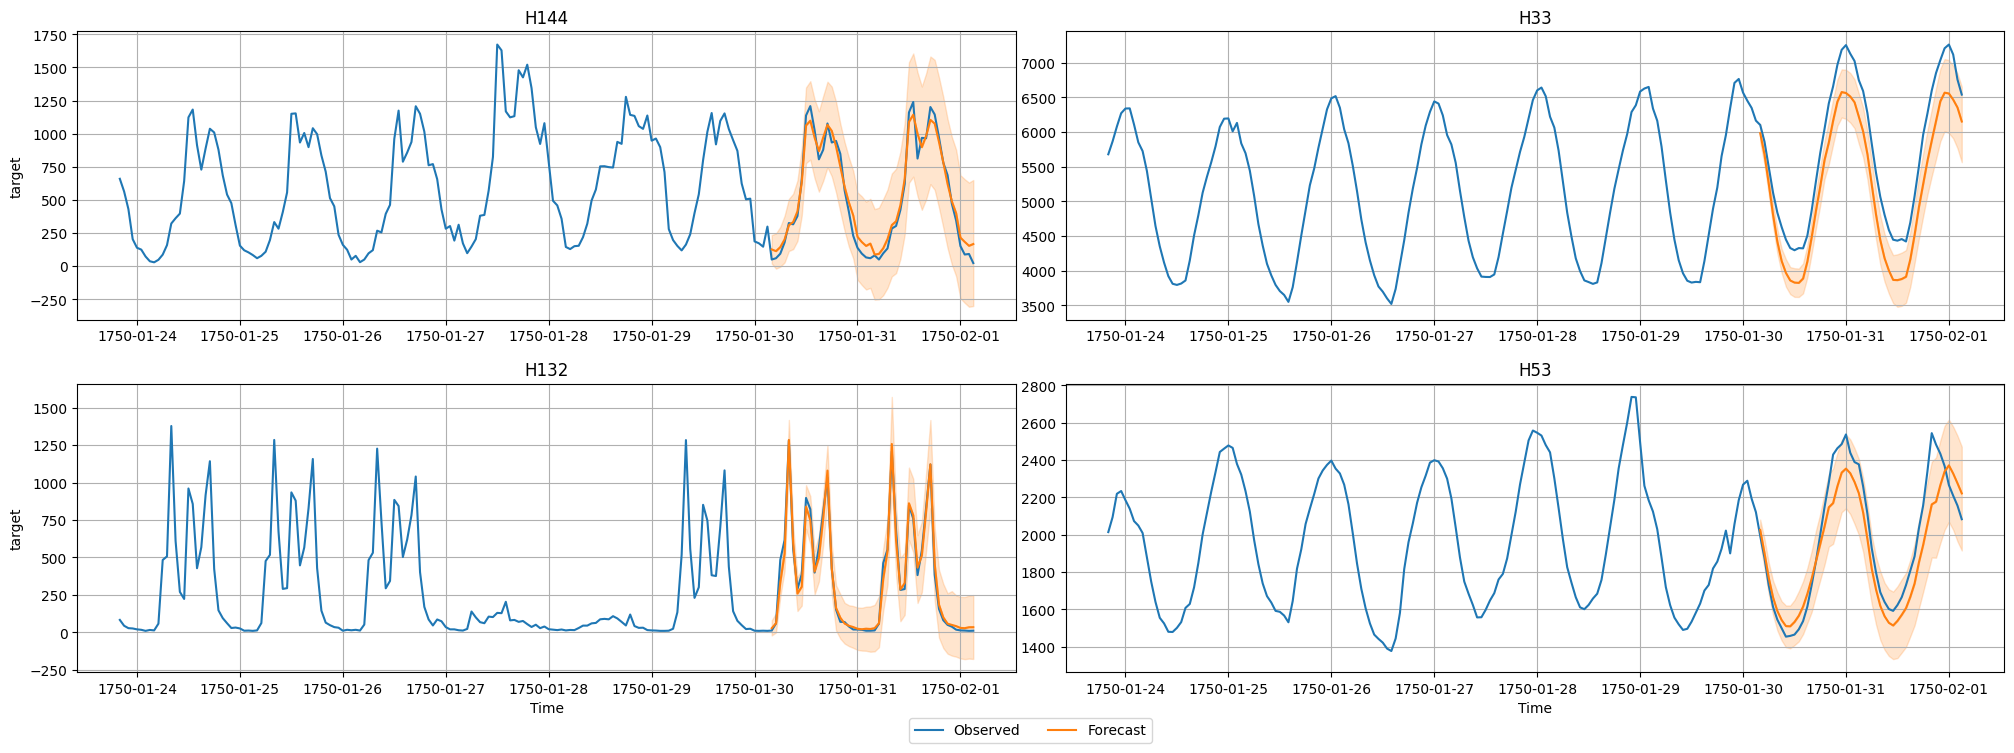

In [6]:
import matplotlib.pyplot as plt

# TimeSeriesDataFrame can also be loaded directly from a file
test_data = TimeSeriesDataFrame.from_path("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly_subset/test.csv")

# Plot 4 randomly chosen time series and the respective forecasts
predictor.plot(test_data, predictions, quantile_levels=[0.1, 0.9], max_history_length=200, max_num_item_ids=4);

## 7. 리더보드로 성능 비교

마지막으로 `leaderboard()`를 실행하면 학습 과정에서 만들어진 여러 모델의 성능을 표 형태로 비교할 수 있습니다.

여기서는 테스트 데이터의 마지막 `prediction_length=48` 구간을 기준으로 평가합니다. 실제로는 보지 못한 미래 48시점을 얼마나 잘 맞췄는가를 비교하는 부분입니다.


In [7]:
# The test score is computed using the last
# prediction_length=48 timesteps of each time series in test_data
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.734879,-0.835566,18.905370,31.803218,0.411520,8
1,Chronos2,-0.765236,-0.877750,2.300708,1.376285,20.624256,6
2,RecursiveTabular,-0.862797,-0.933874,0.306453,0.281429,13.235110,2
3,SeasonalNaive,-1.022854,-1.216909,0.083538,3.043003,0.038723,1
4,DirectTabular,-1.648202,-1.372871,0.240704,0.216684,6.105787,3
5,ETS,-1.806061,-1.965454,15.166360,26.008204,0.034923,4
6,Theta,-1.905367,-2.142551,0.799116,0.870722,0.039526,5
7,TemporalFusionTransformer,-2.185386,-2.472419,0.188594,0.156771,134.082433,7


## 정리

이 노트북에서 한 일은 다음과 같습니다.

1. CSV 데이터를 불러왔다.
2. `TimeSeriesDataFrame`으로 변환해 시계열 구조를 명시했다.
3. `TimeSeriesPredictor`로 여러 모델을 자동 학습했다.
4. 미래 48시점을 예측하고 시각화했다.
5. 리더보드로 모델 성능을 비교했다.
